# Project 11 — Multimodal Fake News Detection
## Data Exploration, Cleaning & Quality Checks

**Dataset:** FakeNewsNet (CSV minimalistic version + downloaded `news content.json` files)  
**Goal:** Understand the data, clean it, and decide what feature engineering is needed before modelling.

### Notebook Structure
1. Setup & paths
2. Load the four CSVs
3. Basic shape & label distribution
4. Missing-value audit
5. Text column exploration (title & article body)
6. Image URL exploration
7. `news content.json` exploration (if downloaded)
8. Tweet-ID column exploration
9. Data cleaning & deduplication
10. Balanced subset construction
11. Summary & next-step checklist

## 1 · Setup & Paths

In [2]:
# ── standard installs (run once) ──────────────────────────────────────────────
# !pip install pandas matplotlib seaborn wordcloud requests tqdm Pillow --quiet

import os, json, re, warnings
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)

# ── colour palette ─────────────────────────────────────────────────────────────
FAKE_CLR  = '#E53935'
REAL_CLR  = '#1E88E5'
PALETTE   = {'fake': FAKE_CLR, 'real': REAL_CLR}

# ── ROOT PATHS  ── adjust these to your local clone of FakeNewsNet ─────────────
# CSV files are in the 'dataset/' folder of the repo
CSV_DIR   = Path('dataset')          # path/to/FakeNewsNet/dataset

# Full downloaded dataset (from running main.py)
# If you have NOT downloaded yet, set FULL_DATA_AVAILABLE = False
FULL_DATA_AVAILABLE = False
DATA_DIR  = Path('fakenewsnet_dataset')   # root of the downloaded folder structure

print('CSV_DIR  exists:', CSV_DIR.exists())
print('DATA_DIR exists:', DATA_DIR.exists() if FULL_DATA_AVAILABLE else 'N/A (not downloaded)')

CSV_DIR  exists: True
DATA_DIR exists: N/A (not downloaded)


## 2 · Load the Four CSVs

In [3]:
def load_csv(source: str, label: str) -> pd.DataFrame:
    """Load one of the four CSVs and attach source/label columns."""
    path = CSV_DIR / f'{source}_{label}.csv'
    df   = pd.read_csv(path)
    df['source'] = source
    df['label']  = label
    return df

pf_fake = load_csv('politifact', 'fake')
pf_real = load_csv('politifact', 'real')
gc_fake = load_csv('gossipcop',  'fake')
gc_real = load_csv('gossipcop',  'real')

raw = pd.concat([pf_fake, pf_real, gc_fake, gc_real], ignore_index=True)

print(f'Total rows: {len(raw):,}')
raw.head(3)

Total rows: 23,196


,id,news_url,title,tweet_ids,source,label
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy Over Kneeling Thugs,937349434668498944\t937379378006282240\t937380068590055425\t937384406511005696\t937387493451862016\t9374007660248965...,politifact,fake
1,politifact15156,politics2020.info/index.php/2018/03/13/court-orders-obama-to-pay-400-million-in-restitution/,Court Orders Obama To Pay $400 Million In Restitution,972666281441878016\t972678396575559680\t972827819993595904\t972828014269448192\t972828016647663616\t9728285718310625...,politifact,fake
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467344/update-second-roy-moore-accuser-works-for-michelle-obama-right-now...,UPDATE: Second Roy Moore Accuser Works For Michelle Obama Right NOW -,929405740732870656\t929439450400264192\t929439484806037506\t929484662145208320\t929498602539450368\t9295037309611253...,politifact,fake


## 3 · Basic Shape & Label Distribution

In [4]:
print('Columns:', raw.columns.tolist())
print('\nShape per (source, label):')
print(raw.groupby(['source', 'label']).size().unstack(fill_value=0))

Columns: ['id', 'news_url', 'title', 'tweet_ids', 'source', 'label']

Shape per (source, label):
label       fake   real
source                 
gossipcop   5323  16817
politifact   432    624


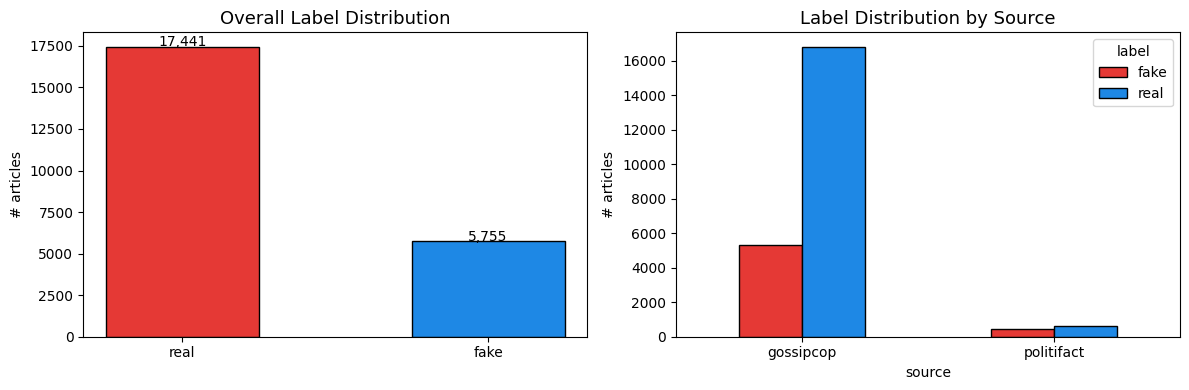


Class imbalance ratio (fake/real):
source
gossipcop     0.316525
politifact    0.692308
Name: ratio, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall label split
counts = raw['label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[FAKE_CLR, REAL_CLR], edgecolor='black', width=0.5)
axes[0].set_title('Overall Label Distribution', fontsize=13)
axes[0].set_ylabel('# articles')
for bar, v in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{v:,}', ha='center', fontsize=10)

# Per-source label split
grp = raw.groupby(['source', 'label']).size().unstack(fill_value=0)
grp.plot(kind='bar', ax=axes[1], color=[FAKE_CLR, REAL_CLR],
         edgecolor='black', rot=0)
axes[1].set_title('Label Distribution by Source', fontsize=13)
axes[1].set_ylabel('# articles')
axes[1].legend(title='label')

plt.tight_layout()
plt.savefig('plot_01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nClass imbalance ratio (fake/real):')
print((raw.groupby(['source', 'label']).size().unstack()
          .assign(ratio=lambda d: d['fake']/d['real']))['ratio'])

## 4 · Missing-Value Audit

In [6]:
def missing_report(df: pd.DataFrame, name: str = ''):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'missing_count': miss, 'missing_%': pct})
    report = report[report['missing_count'] > 0].sort_values('missing_%', ascending=False)
    print(f'--- Missing values: {name} ---')
    print(report if len(report) else '  No missing values.')
    return report

_ = missing_report(raw, 'all data')
print()
for src in ['politifact', 'gossipcop']:
    _ = missing_report(raw[raw['source'] == src], src)

--- Missing values: all data ---
           missing_count  missing_%
tweet_ids           1501       6.47
news_url             330       1.42

--- Missing values: politifact ---
           missing_count  missing_%
tweet_ids            255      24.15
news_url              61       5.78
--- Missing values: gossipcop ---
           missing_count  missing_%
tweet_ids           1246       5.63
news_url             269       1.21


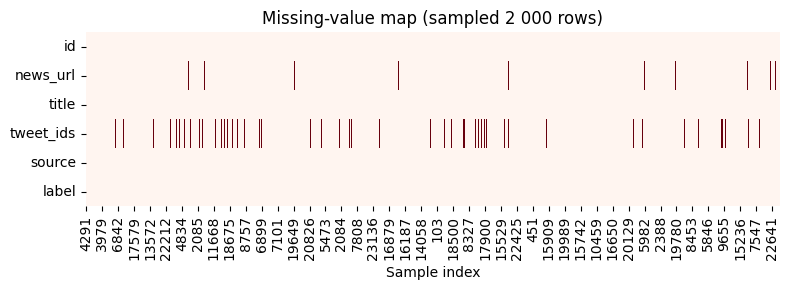

In [7]:
# Visualise missingness as a heatmap
fig, ax = plt.subplots(figsize=(8, 3))
miss_matrix = raw.isnull().astype(int)
# sample at most 2000 rows for visibility
sample_idx  = miss_matrix.sample(min(2000, len(miss_matrix)), random_state=42).index
sns.heatmap(miss_matrix.loc[sample_idx].T, cmap='Reds', cbar=False,
            yticklabels=raw.columns, ax=ax)
ax.set_title('Missing-value map (sampled 2 000 rows)', fontsize=12)
ax.set_xlabel('Sample index')
plt.tight_layout()
plt.savefig('plot_02_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Text Column Exploration (title)

In [8]:
# ── 5.1 Basic string stats ─────────────────────────────────────────────────────
raw['title_len_chars'] = raw['title'].fillna('').str.len()
raw['title_len_words'] = raw['title'].fillna('').str.split().str.len()

print('Title length (characters):')
print(raw.groupby('label')['title_len_chars'].describe().round(1))
print('\nTitle length (words):')
print(raw.groupby('label')['title_len_words'].describe().round(1))

Title length (characters):
         count  mean   std   min   25%   50%   75%    max
label                                                    
fake    5755.0  68.8  23.8  10.0  54.0  69.0  84.0  200.0
real   17441.0  68.1  23.1  10.0  55.0  68.0  83.0  340.0

Title length (words):
         count  mean  std  min  25%   50%   75%   max
label                                                
fake    5755.0  11.1  4.0  1.0  9.0  11.0  14.0  38.0
real   17441.0  11.2  4.0  1.0  9.0  11.0  14.0  53.0


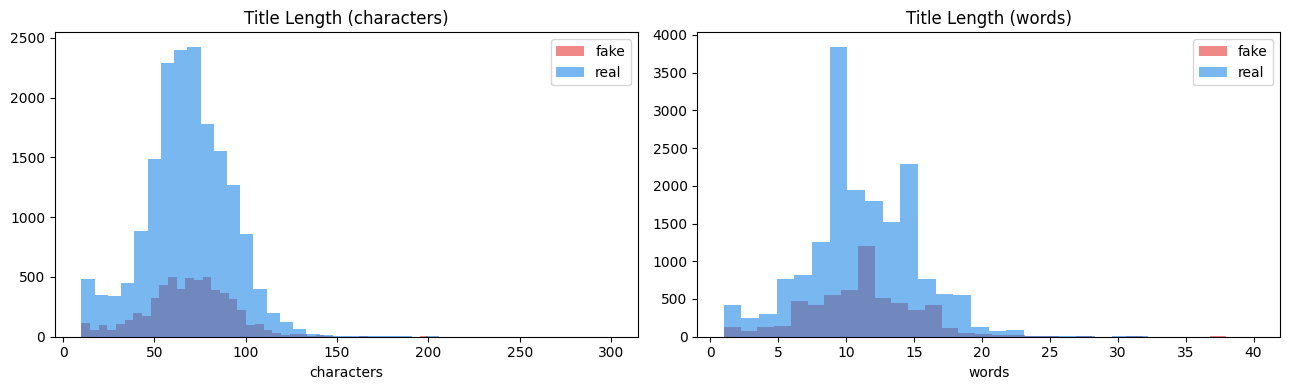

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, grp in raw.groupby('label'):
    axes[0].hist(grp['title_len_chars'].clip(0, 300), bins=40,
                 alpha=0.6, label=label, color=PALETTE[label])
    axes[1].hist(grp['title_len_words'].clip(0, 40), bins=30,
                 alpha=0.6, label=label, color=PALETTE[label])

axes[0].set_title('Title Length (characters)', fontsize=12)
axes[0].set_xlabel('characters'); axes[0].legend()
axes[1].set_title('Title Length (words)',      fontsize=12)
axes[1].set_xlabel('words');      axes[1].legend()

plt.tight_layout()
plt.savefig('plot_03_title_length.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── 5.2 Character-level anomalies ─────────────────────────────────────────────
raw['title_has_null']  = raw['title'].isnull()
raw['title_is_empty']  = raw['title'].fillna('').str.strip().eq('')
raw['title_is_url']    = raw['title'].fillna('').str.startswith('http')
raw['title_all_caps']  = raw['title'].fillna('').apply(
    lambda t: t.isupper() and len(t.split()) > 3)

flags = ['title_has_null', 'title_is_empty', 'title_is_url', 'title_all_caps']
print('Title anomaly counts:')
print(raw[flags].sum().to_string())

Title anomaly counts:
title_has_null     0
title_is_empty     0
title_is_url       1
title_all_caps    49


In [11]:
# ── 5.3 Sample titles per class ───────────────────────────────────────────────
print('=== Sample FAKE titles ===')
print(raw[raw['label']=='fake']['title'].dropna().sample(5, random_state=1).tolist())
print('\n=== Sample REAL titles ===')
print(raw[raw['label']=='real']['title'].dropna().sample(5, random_state=1).tolist())

=== Sample FAKE titles ===
['Why Katie Holmes and Jamie Foxx Never Leave a Dinner Date Together', 'INTO: A Digital Magazine for The Modern Queer World', 'Apology To Sarah Ferguson', 'Celebrities Respond as President Trump Backs Out of Paris Accord – Variety', 'Angelina Jolie ‘Misses’ Connection With Brad Pitt — It Used To Be ‘Them Against The World’']

=== Sample REAL titles ===
['‘Teen Mom OG’ Star Maci Bookout Looks To Have A Baby Bump In New Instagram Photo', 'Jenna Bush Hager', "Exclusive: Go behind the scenes of 'A Wrinkle in Time' with Oprah Winfrey", 'TV Scoop Awards 2017: Vote for the Best Fandom and Best Cast on Social Media Now', "What is Tarek El Moussa's Net Worth?"]


In [12]:
# ── 5.4 Special-character & punctuation density ────────────────────────────────
def punct_density(text: str) -> float:
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    return sum(1 for c in text if not c.isalnum() and c != ' ') / len(text)

def exclamation_count(text: str) -> int:
    return text.count('!') if isinstance(text, str) else 0

def question_count(text: str) -> int:
    return text.count('?') if isinstance(text, str) else 0

raw['title_punct_density']   = raw['title'].apply(punct_density)
raw['title_exclaim_count']   = raw['title'].apply(exclamation_count)
raw['title_question_count']  = raw['title'].apply(question_count)

print('Punctuation density by label:')
print(raw.groupby('label')['title_punct_density'].describe().round(4))
print('\nExclamation marks (total) by label:')
print(raw.groupby('label')['title_exclaim_count'].sum())

Punctuation density by label:
         count    mean     std  min  25%     50%     75%     max
label                                                           
fake    5755.0  0.0266  0.0239  0.0  0.0  0.0230  0.0408  0.2143
real   17441.0  0.0265  0.0249  0.0  0.0  0.0222  0.0405  0.2424

Exclamation marks (total) by label:
label
fake    409
real    977
Name: title_exclaim_count, dtype: int64


## 6 · URL Column Exploration

In [21]:
# ── 6.1 URL presence & domain extraction ──────────────────────────────────────
raw['url_missing'] = raw['news_url'].isnull()

def extract_domain(url):
    try:
        if not isinstance(url, str) or len(str(url).strip()) == 0:
            return 'MISSING'
        url = str(url).strip().lower()
        # First try to match http/https
        m = re.search(r'https?://(?:www\.)?([^/?\#]+)', url)
        if m:
            return m.group(1)
        # If no scheme, try to extract domain directly
        m = re.search(r'^(?:www\.)?([^/?\#]+)', url)
        return m.group(1) if m else 'UNKNOWN'
    except Exception as e:
        return 'ERROR'

raw['domain'] = raw['news_url'].apply(extract_domain)

print('Top 15 domains (fake):')
print(raw[raw['label']=='fake']['domain'].value_counts().head(15))
print('\nTop 15 domains (real):')
print(raw[raw['label']=='real']['domain'].value_counts().head(15))

Top 15 domains (fake):
domain
hollywoodlife.com    460
MISSING              260
people.com           216
dailymail.co.uk      194
radaronline.com      174
eonline.com          154
usmagazine.com       147
imdb.com             145
newidea.com.au       137
en.wikipedia.org     123
inquisitr.com        107
etonline.com          81
intouchweekly.com     75
msn.com               74
web.archive.org       69
Name: count, dtype: int64

Top 15 domains (real):
domain
people.com               1570
dailymail.co.uk           770
en.wikipedia.org          618
etonline.com              585
usmagazine.com            562
longroom.com              562
usatoday.com              300
hollywoodreporter.com     298
variety.com               259
ew.com                    214
today.com                 180
billboard.com             164
thewrap.com               162
time.com                  157
elle.com                  154
Name: count, dtype: int64


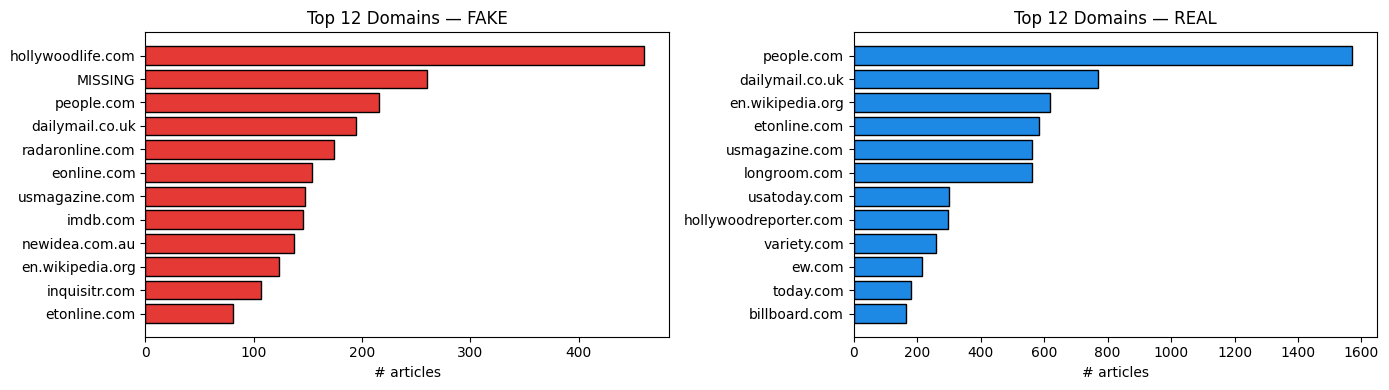

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, label in zip(axes, ['fake', 'real']):
    top = raw[raw['label']==label]['domain'].value_counts().head(12)
    ax.barh(top.index[::-1], top.values[::-1],
            color=PALETTE[label], edgecolor='black')
    ax.set_title(f'Top 12 Domains — {label.upper()}', fontsize=12)
    ax.set_xlabel('# articles')

plt.tight_layout()
plt.savefig('plot_04_domains.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── 6.2 URL length ────────────────────────────────────────────────────────────
raw['url_len'] = raw['news_url'].fillna('').str.len()
print('URL length statistics by label:')
print(raw.groupby('label')['url_len'].describe().round(1))

URL length statistics by label:
         count  mean   std  min   25%   50%    75%    max
label                                                    
fake    5755.0  83.7  33.7  0.0  67.0  86.0  103.0  258.0
real   17441.0  96.2  28.4  0.0  77.0  97.0  114.0  331.0


## 7 · `news content.json` Exploration (article body + images)

In [25]:
# ── 7.1 Load all news content JSON files ─────────────────────────────────────
# This cell only runs if FULL_DATA_AVAILABLE = True

def load_news_content(data_dir: Path) -> pd.DataFrame:
    records = []
    for source in ['politifact', 'gossipcop']:
        for label in ['fake', 'real']:
            folder = data_dir / source / label
            if not folder.exists():
                continue
            for article_dir in folder.iterdir():
                json_path = article_dir / 'news content.json'
                if not json_path.exists():
                    continue
                with open(json_path, 'r', encoding='utf-8', errors='replace') as f:
                    try:
                        content = json.load(f)
                    except json.JSONDecodeError:
                        content = {}
                records.append({
                    'id'          : article_dir.name,
                    'source'      : source,
                    'label'       : label,
                    'text'        : content.get('text', None),
                    'images'      : content.get('images', []),
                    'publish_date': content.get('publish date', None),
                    'top_img'     : content.get('top_img', None),
                    'authors'     : content.get('authors', []),
                    'movies'      : content.get('movies', []),
                    'keywords'    : content.get('keywords', []),
                })
    return pd.DataFrame(records)

if FULL_DATA_AVAILABLE:
    content_df = load_news_content(DATA_DIR)
    print(f'Loaded {len(content_df):,} news content JSON files')
    print(content_df.head(2))
else:
    print('FULL_DATA_AVAILABLE=False — skipping JSON loading.')
    print('Set FULL_DATA_AVAILABLE=True and re-run after running main.py.')
    # Create an empty placeholder so downstream cells don't crash
    content_df = pd.DataFrame(columns=[
        'id','source','label','text','images','publish_date','top_img','authors','movies','keywords'
    ])

FULL_DATA_AVAILABLE=False — skipping JSON loading.
Set FULL_DATA_AVAILABLE=True and re-run after running main.py.


In [26]:
# ── 7.2 Article body text stats ───────────────────────────────────────────────
if not content_df.empty:
    content_df['text_len_words'] = content_df['text'].fillna('').str.split().str.len()
    content_df['text_len_chars'] = content_df['text'].fillna('').str.len()
    content_df['text_missing']   = content_df['text'].isnull() | content_df['text'].fillna('').str.strip().eq('')

    print('Article body word-count by label:')
    print(content_df.groupby('label')['text_len_words'].describe().round(1))

    print('\nArticle body missing / empty by label:')
    print(content_df.groupby('label')['text_missing'].sum())

    fig, ax = plt.subplots(figsize=(10, 4))
    for label, grp in content_df.groupby('label'):
        ax.hist(grp['text_len_words'].clip(0, 3000), bins=60,
                alpha=0.6, label=label, color=PALETTE[label])
    ax.set_title('Article Body Length (words)', fontsize=12)
    ax.set_xlabel('words'); ax.legend()
    plt.tight_layout()
    plt.savefig('plot_05_body_length.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No content_df to analyse — set FULL_DATA_AVAILABLE=True.')

No content_df to analyse — set FULL_DATA_AVAILABLE=True.


In [27]:
# ── 7.3 Image URL analysis ────────────────────────────────────────────────────
if not content_df.empty:
    content_df['n_images']       = content_df['images'].apply(
        lambda x: len(x) if isinstance(x, list) else 0)
    content_df['has_image']      = content_df['n_images'] > 0
    content_df['has_top_img']    = content_df['top_img'].notna() & content_df['top_img'].ne('')

    print('Image availability by label:')
    print(content_df.groupby('label')[['has_image','has_top_img']]
          .mean().mul(100).round(1).rename(columns=str).add_suffix(' %'))

    print('\nNumber of images per article by label:')
    print(content_df.groupby('label')['n_images'].describe().round(1))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # has_image bar
    avail = content_df.groupby(['label','has_image']).size().unstack(fill_value=0)
    avail.plot(kind='bar', ax=axes[0], color=['#B0BEC5','#66BB6A'], edgecolor='black', rot=0)
    axes[0].set_title('Articles With / Without Images', fontsize=12)
    axes[0].set_ylabel('count'); axes[0].legend(['no image','has image'])

    # n_images distribution
    for label, grp in content_df.groupby('label'):
        axes[1].hist(grp['n_images'].clip(0, 20), bins=20,
                     alpha=0.6, label=label, color=PALETTE[label])
    axes[1].set_title('Number of Images per Article', fontsize=12)
    axes[1].set_xlabel('# images'); axes[1].legend()

    plt.tight_layout()
    plt.savefig('plot_06_image_stats.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No content_df — skipping image analysis.')

No content_df — skipping image analysis.


In [28]:
# ── 7.4 Image URL format check ────────────────────────────────────────────────
if not content_df.empty:
    def audit_image_urls(images):
        if not isinstance(images, list):
            return pd.Series({'total':0, 'http':0, 'no_ext':0, 'svg':0})
        http  = sum(1 for u in images if isinstance(u, str) and u.startswith('http'))
        svg   = sum(1 for u in images if isinstance(u, str) and u.lower().endswith('.svg'))
        no_ext= sum(1 for u in images if isinstance(u, str)
                    and not any(u.lower().endswith(e)
                                for e in ['.jpg','.jpeg','.png','.gif','.webp','.svg']))
        return pd.Series({'total': len(images), 'http': http,
                          'no_ext': no_ext, 'svg': svg})

    url_audit = content_df['images'].apply(audit_image_urls)
    print('Image URL audit (totals across whole dataset):')
    print(url_audit.sum().astype(int))

    # Extension frequency
    all_urls = [u for imgs in content_df['images'] if isinstance(imgs, list)
                for u in imgs if isinstance(u, str)]
    exts = Counter(
        re.search(r'\.([a-zA-Z0-9]+)(?:\?|$)', u).group(1).lower()
        if re.search(r'\.([a-zA-Z0-9]+)(?:\?|$)', u) else 'no_ext'
        for u in all_urls
    )
    ext_df = pd.Series(exts).sort_values(ascending=False).head(10)
    print('\nImage extension frequency (top 10):')
    print(ext_df)
else:
    print('No content_df — skipping image URL audit.')

No content_df — skipping image URL audit.


In [29]:
# ── 7.5 Publish-date exploration ──────────────────────────────────────────────
if not content_df.empty and 'publish_date' in content_df.columns:
    content_df['publish_dt'] = pd.to_datetime(
        content_df['publish_date'], errors='coerce', utc=True)
    content_df['pub_year'] = content_df['publish_dt'].dt.year

    print('Publish year range:', content_df['pub_year'].min(),
          '—', content_df['pub_year'].max())
    print('Missing publish date:',
          content_df['publish_date'].isnull().sum(),
          f'({content_df["publish_date"].isnull().mean()*100:.1f}%)')

    fig, ax = plt.subplots(figsize=(10, 4))
    for label, grp in content_df.groupby('label'):
        yr = grp['pub_year'].value_counts().sort_index()
        ax.plot(yr.index, yr.values, marker='o', label=label, color=PALETTE[label])
    ax.set_title('Articles per Year by Label', fontsize=12)
    ax.set_xlabel('year'); ax.set_ylabel('# articles'); ax.legend()
    plt.tight_layout()
    plt.savefig('plot_07_publish_year.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No publish_date to analyse.')

No publish_date to analyse.


## 8 · Tweet-ID Column Exploration

In [30]:
# tweet_ids column is tab-separated inside the CSV string
def count_tweets(val):
    if pd.isnull(val):
        return 0
    return len(str(val).split('\t'))

raw['n_tweet_ids'] = raw['tweet_ids'].apply(count_tweets)

print('Tweet-ID count statistics by label:')
print(raw.groupby('label')['n_tweet_ids'].describe().round(1))

print('\nArticles with NO tweet IDs by label:')
print(raw[raw['n_tweet_ids']==0].groupby('label').size())

Tweet-ID count statistics by label:
         count   mean    std  min   25%   50%   75%      max
label                                                       
fake    5755.0  132.7  548.2  0.0   5.0  13.0  51.0  29060.0
real   17441.0   74.5  466.5  0.0  17.0  44.0  66.0  27377.0

Articles with NO tweet IDs by label:
label
fake     228
real    1273
dtype: int64


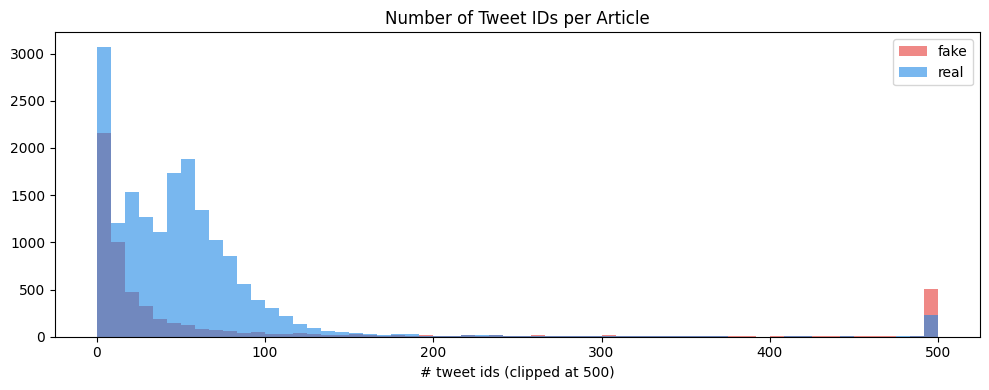

In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, grp in raw.groupby('label'):
    ax.hist(grp['n_tweet_ids'].clip(0, 500), bins=60,
            alpha=0.6, label=label, color=PALETTE[label])
ax.set_title('Number of Tweet IDs per Article', fontsize=12)
ax.set_xlabel('# tweet ids (clipped at 500)'); ax.legend()
plt.tight_layout()
plt.savefig('plot_08_tweet_ids.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Data Cleaning & Deduplication

In [32]:
# ── 9.1 Exact duplicate IDs ───────────────────────────────────────────────────
print('Duplicate article IDs (same id, same source):')
dups = raw[raw.duplicated(subset=['id', 'source'], keep=False)]
print(f'  {len(dups):,} rows involved in {dups.groupby(["id","source"]).ngroups:,} duplicate groups')

# Inspect any duplicates that disagree on label (critical data quality issue)
label_conflict = (raw.groupby(['id','source'])['label']
                    .nunique()
                    .reset_index(name='n_labels')
                    .query('n_labels > 1'))
print(f'\nLabel-conflicting duplicates: {len(label_conflict)}')
if len(label_conflict):
    print(label_conflict.head(10))

Duplicate article IDs (same id, same source):
  4 rows involved in 2 duplicate groups

Label-conflicting duplicates: 2
                    id      source  n_labels
22597  politifact14920  politifact         2
22600  politifact14940  politifact         2


In [33]:
# ── 9.2 Duplicate titles ──────────────────────────────────────────────────────
dup_titles = raw[raw.duplicated(subset=['title'], keep=False) & raw['title'].notna()]
print(f'Rows with duplicate titles: {len(dup_titles):,}')
# Show a sample of cross-label title duplicates
cross = (dup_titles.groupby('title')['label'].nunique() > 1)
cross_titles = cross[cross].index.tolist()
print(f'Titles that appear as BOTH fake and real: {len(cross_titles)}')
if cross_titles:
    print(dup_titles[dup_titles['title'].isin(cross_titles[:3])]
          [['id','source','label','title']])

Rows with duplicate titles: 2,435
Titles that appear as BOTH fake and real: 123
                         id     source label  \
1585    gossipcop-658317851  gossipcop  fake   
4904   gossipcop-6345913771  gossipcop  fake   
5688   gossipcop-1760401680  gossipcop  fake   
15329      gossipcop-907816  gossipcop  real   
21656      gossipcop-871199  gossipcop  real   
21914      gossipcop-866572  gossipcop  real   

                                                                                         title  
1585                                2017 Emmy Nominees List: See All the Nominations – Variety  
4904   'The Bachelorette' Finale: Engaged Rachel Lindsay Reveals Her Winner in Historic Season  
5688                           2018 SAG Award Nominations: See Full List of Nominees – Variety  
15329                          2018 SAG Award Nominations: See Full List of Nominees – Variety  
21656  'The Bachelorette' Finale: Engaged Rachel Lindsay Reveals Her Winner in Historic Season  
2

In [34]:
# ── 9.3 Clean: remove duplicates, drop missing titles, strip whitespace ────────
clean = raw.copy()

# Strip leading/trailing whitespace from text columns
for col in ['title', 'url']:
    if col in clean.columns:
        clean[col] = clean[col].str.strip()

# Drop rows where title is null or empty (can't classify without any text signal)
before = len(clean)
clean = clean[clean['title'].notna() & clean['title'].ne('')]
print(f'Dropped {before - len(clean)} rows with null/empty title')

# Keep first occurrence of each (id, source) pair
before = len(clean)
clean = clean.drop_duplicates(subset=['id', 'source'], keep='first')
print(f'Dropped {before - len(clean)} duplicate (id, source) rows')

print(f'\nClean dataset shape: {clean.shape}')
print(clean.groupby(['source','label']).size().unstack())

Dropped 0 rows with null/empty title
Dropped 2 duplicate (id, source) rows

Clean dataset shape: (23194, 19)
label       fake   real
source                 
gossipcop   5323  16817
politifact   432    622


In [35]:
# ── 9.4 If full content available: merge & flag usable rows ───────────────────
if FULL_DATA_AVAILABLE and not content_df.empty:
    clean = clean.merge(
        content_df[['id','source','text','images','publish_date',
                    'top_img','has_image','n_images','text_missing']],
        on=['id','source'], how='left'
    )

    # Flag rows usable for multimodal training
    clean['usable_text']  = ~clean['text_missing'].fillna(True)
    clean['usable_image'] = clean['has_image'].fillna(False)
    clean['usable_both']  = clean['usable_text'] & clean['usable_image']

    print('Usability flags:')
    print(clean[['usable_text','usable_image','usable_both']]
          .mean().mul(100).round(1).rename('% usable'))

    print('\nUsable for BOTH modalities by (source, label):')
    print(clean[clean['usable_both']].groupby(['source','label']).size().unstack())
else:
    print('Full content not available — usability flags skipped.')
    # Add placeholder flags based on what we do have
    clean['usable_text']  = clean['title'].notna()
    clean['usable_image'] = False
    clean['usable_both']  = False

Full content not available — usability flags skipped.


## 10 · Balanced Subset Construction

In [36]:
# ── 10.1 Strategy ─────────────────────────────────────────────────────────────
# For the multimodal model we need articles that have BOTH text and at least one image.
# We balance fake / real within each source to avoid source-label confounding.

SEED       = 42
N_PER_CLASS = 100   # SMALL-SCALE BASELINE: 100 per (source × label) — scale up after review

# Pool to draw from: prefer usable_both if available, else fall back to title-only
if FULL_DATA_AVAILABLE and not content_df.empty:
    pool = clean[clean['usable_both']].copy()
    print(f'Multimodal pool: {len(pool):,} articles (text + image both available)')
else:
    pool = clean.copy()          # fallback: title-only mode
    print(f'Title-only pool: {len(pool):,} articles (working with CSV data only)')

print('\nAvailable samples per (source, label):')
print(pool.groupby(['source','label']).size().unstack())

Title-only pool: 23,194 articles (working with CSV data only)

Available samples per (source, label):
label       fake   real
source                 
gossipcop   5323  16817
politifact   432    622


In [37]:
# ── 10.2 Sample balanced subsets ─────────────────────────────────────────────
def balanced_sample(df, n_per_class, seed=42):
    parts = []
    for (src, lbl), grp in df.groupby(['source','label']):
        n = min(n_per_class, len(grp))
        parts.append(grp.sample(n, random_state=seed))
        print(f'  {src}/{lbl}: sampled {n:,} (available {len(grp):,})')
    return pd.concat(parts, ignore_index=True)

subset = balanced_sample(pool, N_PER_CLASS, seed=SEED)

# Train / val / test split  (80 / 10 / 10), stratified by source+label
from sklearn.model_selection import train_test_split

train_val, test = train_test_split(
    subset, test_size=0.10, stratify=subset[['source','label']], random_state=SEED)
train, val = train_test_split(
    train_val, test_size=0.111, stratify=train_val[['source','label']], random_state=SEED)

print(f'\nSplit sizes — train: {len(train):,}  val: {len(val):,}  test: {len(test):,}')
print('\nTrain label distribution:')
print(train.groupby(['source','label']).size().unstack())

  gossipcop/fake: sampled 100 (available 5,323)
  gossipcop/real: sampled 100 (available 16,817)
  politifact/fake: sampled 100 (available 432)
  politifact/real: sampled 100 (available 622)

Split sizes — train: 320  val: 40  test: 40

Train label distribution:
label       fake  real
source                
gossipcop     80    80
politifact    80    80


In [38]:
# ── 10.3 Save splits ──────────────────────────────────────────────────────────
os.makedirs('data_splits', exist_ok=True)

train.to_csv('data_splits/train.csv', index=False)
val.to_csv(  'data_splits/val.csv',   index=False)
test.to_csv( 'data_splits/test.csv',  index=False)

# Also save the full clean dataframe for reference
clean.to_csv('data_splits/clean_full.csv', index=False)

print('Saved:')
print('  data_splits/train.csv       —', len(train), 'rows')
print('  data_splits/val.csv         —', len(val),   'rows')
print('  data_splits/test.csv        —', len(test),  'rows')
print('  data_splits/clean_full.csv  —', len(clean), 'rows')

Saved:
  data_splits/train.csv       — 320 rows
  data_splits/val.csv         — 40 rows
  data_splits/test.csv        — 40 rows
  data_splits/clean_full.csv  — 23194 rows


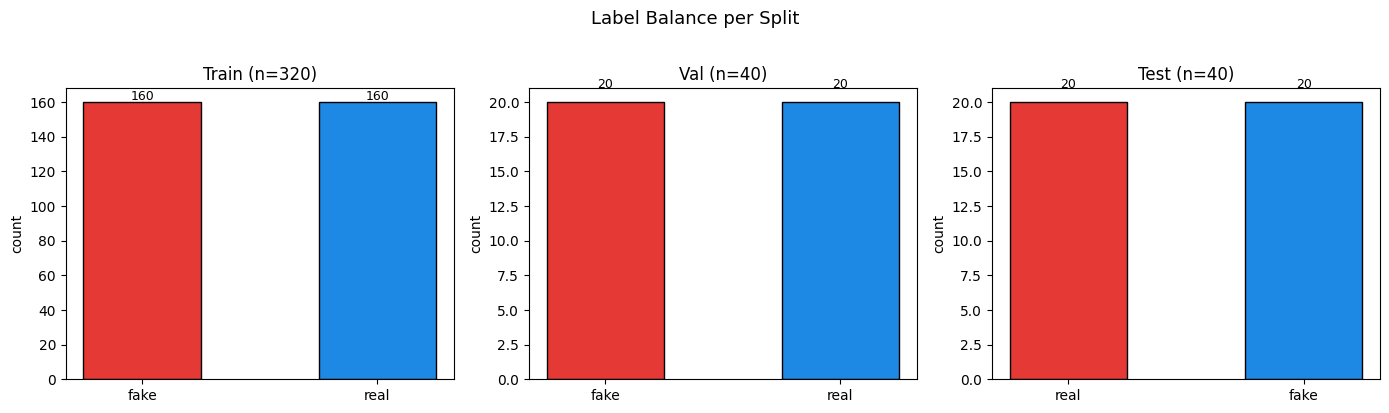

In [39]:
# ── 10.4 Final split visualisation ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (split_name, split_df) in zip(axes, [('Train', train), ('Val', val), ('Test', test)]):
    counts = split_df['label'].value_counts()
    ax.bar(counts.index, counts.values,
           color=[FAKE_CLR, REAL_CLR], edgecolor='black', width=0.5)
    ax.set_title(f'{split_name} (n={len(split_df)})', fontsize=12)
    ax.set_ylabel('count')
    for bar, v in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1, str(v), ha='center', fontsize=9)

plt.suptitle('Label Balance per Split', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_09_split_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 11 · Summary & Next-Step Checklist

Run this cell after completing all sections above. It prints a structured checklist
of findings and recommended next steps for feature engineering and modelling.

In [40]:
divider = '=' * 65

print(divider)
print('EXPLORATION SUMMARY')
print(divider)

print(f'\n[DATA SIZES]')
print(f'  Raw rows loaded          : {len(raw):,}')
print(f'  After cleaning           : {len(clean):,}')
print(f'  Balanced subset (all)    : {len(subset):,}')
print(f'  Train / Val / Test       : {len(train):,} / {len(val):,} / {len(test):,}')

print(f'\n[CLASS BALANCE]')
for lbl, cnt in clean['label'].value_counts().items():
    print(f'  {lbl:6s}: {cnt:,}')

print(f'\n[MISSING VALUES — clean set]')
for col, cnt in clean.isnull().sum().items():
    if cnt > 0:
        print(f'  {col:30s}: {cnt:,} ({cnt/len(clean)*100:.1f}%)')

if FULL_DATA_AVAILABLE and 'usable_both' in clean.columns:
    print(f'\n[MULTIMODAL READINESS]')
    print(f'  Has text body            : {clean["usable_text"].sum():,} '
          f'({clean["usable_text"].mean()*100:.1f}%)')
    print(f'  Has at least 1 image URL : {clean["usable_image"].sum():,} '
          f'({clean["usable_image"].mean()*100:.1f}%)')
    print(f'  Both text + image        : {clean["usable_both"].sum():,} '
          f'({clean["usable_both"].mean()*100:.1f}%)')

print(f'\n{divider}')
print('RECOMMENDED NEXT STEPS (send output to Claude to confirm)')
print(divider)
checklist = [
    'TEXT: Confirm DistilBERT token-length coverage (target: < 5% truncated at 512 tok)',
    'TEXT: Check if body text or title is more discriminative — run TF-IDF LogReg on each',
    'TEXT: Consider concatenating title + first 200 words of body as unified text input',
    'IMAGE: Verify image URLs are reachable (HTTP 200) — report % broken links',
    'IMAGE: Check image resolution distribution — resize strategy for ResNet-18 (224x224)',
    'IMAGE: Flag images that are logos/icons (< 10KB) vs. editorial photos (> 50KB)',
    'BALANCE: Confirm train/val/test label counts are equal fake/real after splitting',
    'FEATURE ENG: title_exclaim_count, title_punct_density as auxiliary features?',
    'FEATURE ENG: n_tweet_ids (social engagement proxy) — consider as side feature',
    'FEATURE ENG: domain as categorical feature (encode top-50 domains)',
    'FEATURE ENG: publish_year as temporal feature if date coverage spans multiple years',
    'MODELLING: Decide whether to use title-only or title+body for text encoder input',
]
for i, item in enumerate(checklist, 1):
    print(f'  [{i:02d}] {item}')

print(f'\n{divider}')
print('SAVED FILES')
print(divider)
for fn in sorted(Path('.').glob('plot_*.png')):
    print(f'  {fn}')
for fn in sorted(Path('data_splits').glob('*.csv')):
    print(f'  {fn}')

EXPLORATION SUMMARY

[DATA SIZES]
  Raw rows loaded          : 23,196
  After cleaning           : 23,194
  Balanced subset (all)    : 400
  Train / Val / Test       : 320 / 40 / 40

[CLASS BALANCE]
  real  : 17,439
  fake  : 5,755

[MISSING VALUES — clean set]
  news_url                      : 330 (1.4%)
  tweet_ids                     : 1,501 (6.5%)

RECOMMENDED NEXT STEPS (send output to Claude to confirm)
  [01] TEXT: Confirm DistilBERT token-length coverage (target: < 5% truncated at 512 tok)
  [02] TEXT: Check if body text or title is more discriminative — run TF-IDF LogReg on each
  [03] TEXT: Consider concatenating title + first 200 words of body as unified text input
  [04] IMAGE: Verify image URLs are reachable (HTTP 200) — report % broken links
  [05] IMAGE: Check image resolution distribution — resize strategy for ResNet-18 (224x224)
  [06] IMAGE: Flag images that are logos/icons (< 10KB) vs. editorial photos (> 50KB)
  [07] BALANCE: Confirm train/val/test label counts are 